Deep Learning Model Report
==========================
***Multiclass Classification Model***


# Executive Summary / Key Results
## Key Results

**Project:** Multiclass News Classification using Deep Learning

**Dataset:** AG News Dataset  
**Classes:** World, Sports, Business, Sci/Tech  
**Task:** Four-class text classification

**Model:** Feed-forward neural network  
**Final architecture:** 128 → 64 → 4  
**Activations:** ReLU → ReLU → Softmax  
**Optimizer:** RMSprop  
**Loss function:** Categorical Crossentropy  
**Epochs:** 3

**Final Results**
- Test accuracy: **90.20%**
- Overall correct predictions: **6,855 / 7,600**
- Baseline accuracy for four balanced classes: **25%**
- Improvement over baseline: approximately **+65 percentage points**

**Main Findings**
- Simple Hold-Out Validation performed similarly to K-Fold Validation while requiring fewer computational resources.
- The model began to overfit after approximately 3 epochs.
- Hyperparameter tuning produced only small improvements after the initial strong baseline.
- The Sports class had the strongest classification performance.

**Learning Outcomes**
- Text preprocessing and vectorization are essential for neural network text classification.
- More model complexity does not always improve generalization.
- Validation strategy affects both model confidence and computational cost.

# Introduction and Background Information
## Introduction
The purpose of this project is to demonstrate an understanding of Deep Learning concepts through the implementation and evaluation of a neural network classification model. The report will explain these concepts through research into the model components and its implementation on a data set.
## Aims and Objectives
The aim of this project is to explain the implementation and  functionality of a Deep Learning Model.
The objectives are the following:
1. Present a research about the data provenance 
2. Describe the deep learning model definitions, applications and principles.
3. Implement a Deep Learning model by following “the universal workflow of Machine Learning” [Chollet 4.5]
4. Describe the model by evaluating the preparation and functionality. 
5. Conclude by analyzing the process of the project 
## Data
### Data Provenance 
The dataset used in this project comes from the TensorFlow Datasets libraries. “TensorFlow Datasets is a collection of datasets ready to use, with TensorFlow or other Python ML frameworks, such as Jax” (“TensorFlow Datasets: a collection of ready-to-use datasets.”). These datasets provide easy handling when creating complex models. 
### AG’s News Subset Dataset 
The dataset chosen for the purpose of this project is “ag_news_subset”(AG’s Dataset). These dataset can be found in the TensorFlow list of datasets. 
Ag’s Dataset “is a collection of more than 1 million news articles” [“ag_news_subset”]. It was gathered by ComeToMyHand, an “academic news search engine” [“ag_news_subset”]. This dataset can be used for non-commercial use as stipulated in the documentation.
AG’s dataset contains four classes of “30,000 training samples and 1,900 testing samples with a total of 120,000 and testing 7,600” [“ag_news_subset”].
#### Links for AG’s Dataset Information
[AG's corpus of news articles (unipi.it)](http://groups.di.unipi.it/~gulli/AG_corpus_of_news_articles.html)  
[AG News Dataset | Papers With Code](https://paperswithcode.com/described as followset/ag-news)  
[1509.01626.pdf (arxiv.org)](https://arxiv.org/pdf/1509.01626.pdf)  



# Model Implementation Workflow
In the book Deep Learning with Python, François Chollet shows “the universal workflow of  machine learning” [Chollet 4.5]. It is defined as a “universal blueprint” [Chollet 4.5] to better understand the development of a machine learning model. 
For the purpose of this project, I will use this workflow for developing, training and testing the model.
## Problem Definition and Resources Availability
### Define the Problem
The model needs to predict the labels of AG’s unseen data. To predict these labels the model needs to be trained in AG’s training data set to learn the patterns in the data. 
#### Data availability  
The data used in this report is the “ag_news_subset” dataset. It is composed of:  
Four classes:
 * World  
 * Sports
 * Business
 * Sci/Tech  
 
Each class contains:  
 * 30,000 training samples (120,000 in total) 
 * 1,900 testing samples (7,600 in total)
 
The data is composed of the following features:  
 * Titles as string
 * Descriptions as string
 * Labels as integer  

In [1]:
import numpy as np
import tensorflow as tf
import gc
import warnings
warnings.filterwarnings('ignore') 

I0000 00:00:1782503238.201839  400549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782503238.571464  400549 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782503240.268452  400549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# import data from  csv file
def import_data(file_name):
    import csv
    with open(file_name, "r") as file:
        return list(csv.reader(file, delimiter=","))

In [3]:
# Explore imported data
train_data = import_data("train.csv")
test_data = import_data("test.csv")
train_data = np.array(train_data[1:])
test_data = np.array(test_data[1:])
print("Training data set size: ", len(train_data))
print("Test data set size: ", len(test_data))
print("Training data set shape: ", train_data.shape)
print("Test data set shape: ", test_data.shape)
print("First example: \t", train_data[0])

Training data set size:  120000
Test data set size:  7600
Training data set shape:  (120000, 3)
Test data set shape:  (7600, 3)
First example: 	 ['3' 'Wall St. Bears Claw Back Into the Black (Reuters)'
 "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."]


#### Data suitability 
Two of the features are the **title** and the **description** that can be combined as one feature for better model performance.  

In [4]:
# Due to having two input columns, data is merged into one input column 
train_data_merged = np.asarray([(train_data[i, 0], train_data[i, 1] + ' ' + train_data[i, 2]) for i in range(len(train_data))])
test_data_merged = np.asarray([(test_data[i, 0], test_data[i, 1] + ' ' + test_data[i, 2]) for i in range(len(test_data))])

print("train_data_merged \t size: ", len(train_data_merged), "\t shape: ", np.asarray(train_data_merged).shape, "\t type: ", type(train_data_merged[0]))
print("test_data_merged  \t size: ", len(test_data_merged), "\t shape: ", np.asarray(test_data_merged).shape, "\t type: ", type(test_data_merged[0]))

train_data_merged 	 size:  120000 	 shape:  (120000, 2) 	 type:  <class 'numpy.ndarray'>
test_data_merged  	 size:  7600 	 shape:  (7600, 2) 	 type:  <class 'numpy.ndarray'>


Another function was created to separate the labels from the input feature:

In [5]:
# separates the data into labels and input data
def separateXY(data):
    x = np.array(data[:, 1])
    y = np.array(data[:, 0])
    return x, y

After looking at the possible solutions, the following functions were created to convert the data into a sequence of numbers once the validation method is chosen. 


In [6]:
# function to create a dictionary of a sequence of words index from the dataset
def dataDict(data, num_words=None):
    from tensorflow.keras.preprocessing.text import Tokenizer
    import operator
    
    # ----https://machinelearningmastery.com/prepare-text-data-deep-learning-keras/ ----    
    # create the tokenizer
    t = Tokenizer()
    # fit the tokenizer on the documents
    t.fit_on_texts(data)   

    # ---------------------------------------------------------------------------------- 
    
    # ----https://stackoverflow.com/questions/613183/how-do-i-sort-a-dictionary-by-value ----    
    # sorts the words from the most appearance to the least
    sorted_arr = sorted(t.word_counts.items(), key=operator.itemgetter(1), reverse=True)
    # ----------------------------------------------------------------------------------
    
    # replace  the number of apperances by the place in the sorted list and creates a dictionary
    if num_words == None:
        sorted_dict = dict([(word[0], i) for word, i in zip(sorted_arr, range(1, len(sorted_arr) + 1))])
    else:
        sorted_dict = dict([(word[0], i) for word, i in zip(sorted_arr, range(1, len(sorted_arr) + 1))][:num_words-1])
    
    return sorted_dict

#### Type of problem or task to solve with the model
The training and test data have two columns one for the text and one for classes. As the following code shows there are four numbers of classes or labels. 

In [7]:
# Extract information from dataset

# shape of data
print("train_data_merged \t shape: ", np.asarray(train_data_merged).shape)
print("test_data_merged  \t shape: ", np.asarray(test_data_merged).shape)
# number of classes
print("training labels: \t", np.unique(train_data_merged[:, 0]))
print("test labels: \t", np.unique(train_data_merged[:, 0]))

train_data_merged 	 shape:  (120000, 2)
test_data_merged  	 shape:  (7600, 2)
training labels: 	 ['1' '2' '3' '4']
test labels: 	 ['1' '2' '3' '4']


As mentioned in the data set information these classes are “the 4 largest classes (“World”, “Sports”, “Business”, “Sci/Tech”) of AG’s Corpus” [ “AG News Dataset”]. 
* Since we have four possible classes for each news article this is a problem of multi-class classification. 
* And by classifying each article in only one label, the problem is also a single-label classification.

Therefore, the problem for this classification model is **single-label, multi-class classification**. 
A problem may arise from the fact that most of the data is not evenly distributed. Therefore, the data will be shuffled before using it. This data shuffling may be beneficial to the Simple Hold-out model. Shuffling the data helps to represent the population correctly when using the training, validation and test sets.


In [8]:
# Shuffle data before using 
np.random.shuffle(train_data_merged)

### Validation Protocol 
* **Simple Hold-Out Validation:** 

In [9]:
# Divide data into training and validation data
def separateHoldOut(data, x_percentage):
    lenTrain = int(len(data) * x_percentage / 100)
    train = data[:lenTrain]
    val = data[lenTrain:]
    return train, val 

### Data Preparations
#### Data Preprocessing

##### Formatting 
The data preparation and formatting will be done in the following function that will be called for each validation method chosen. This method will convert each set of data to a sequence of integers 


In [10]:
# tokenize(text into words) each text string
def tokenizeText(text):
    from tensorflow.keras.preprocessing.text import text_to_word_sequence
        
    # ----https://machinelearningmastery.com/prepare-text-data-deep-learning-keras/ ----
    # tokenize the document
    words = text_to_word_sequence(text)
    return words
    # ----------------------------------------------------------------------------------  

In [11]:
# Features encoded as indeces of a dictionary of words
def encodeToInts(tokenWords, vocabulary):
    intList = []
    for word, i in zip(tokenWords, range(len(tokenWords))):
        if word in vocabulary:
            intList.append(vocabulary[word])
        else:
            intList.append(0)
    return intList

In [12]:
# create a function for data preprocessing (x_train, x_val, x_test) to be called on each validation method 
def dataPrep(trainX, valX, testX, num_words):
    vocab = dataDict(trainX, num_words)
    train = np.array([encodeToInts(tokenizeText(row), vocab) for row in trainX], dtype="object")
    val = np.array([encodeToInts(tokenizeText(row), vocab)  for row in valX], dtype="object")
    test = np.array([encodeToInts(tokenizeText(row), vocab)  for row in testX], dtype="object")
    return train, val, test

#### Vectorization
The following functions will be used to convert the training, validation and test data to tensors of floating points.
There are two options to encode the data and labels: 
* Label Encoding
Is a vectorization method where an integer replaces each value of  the data based on a vocabulary or dictionary. This method is best used when the data can be ranked or information can be extracted when using mathematical or statistical operations in a meaningful manner.
* One-Hot Encoding
This vectorization method replaces the values with binary values, each value present in the data is represented with **1** while the rest of the spaces are represented with **0**.  It is best used where data “doesn't have inherent order or rank among the categories” [T]. 

The tensors of integers need to be vectorized with One-Hot Encodings that “allows us to capture the nominal relationship between the categories” [T].  

In [13]:
# Calculate the maximum size of the tensors
def max_len_tensor(datasets):
    return max(max(max(seq) for seq in d_set) for d_set in datasets)

def max_num_labels(labels_sets):
    return int(max(max(l_set) for l_set in labels_sets))

In [14]:
# ----- https://livebook.manning.com/book/deep-learning-with-python/chapter-3/208 ------
def vectorize_sequences(sequences, dimension):
    # results = np.zeros((len(sequences), dimension + 1))
    results = np.zeros((len(sequences), dimension + 1), dtype=np.float32)
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

# Labels encoded as one_hot encoding
def to_one_hot(labels, dimension):
    labels = np.array(labels, dtype=int)
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label - 1] = 1.
    return results
# ----------------------------------------------------------------------------------  

The following function are used for formatting and vectorization of the data

In [15]:
# Data Preparation

def dataPreparation(train_dataset, test_dataset, train_perc):
    
    # Separate training, validation and test set
    train_data, val_data = separateHoldOut(train_dataset, train_perc)
    
    # Separate x data from labels from training, validation and test set
    xy_train = separateXY(train_data)
    xy_val = separateXY(val_data)
    xy_test = separateXY(test_dataset)

    # Data Preprocesing (create vocabulary, tokenize, encode x data)
    encoded_data = dataPrep(xy_train[0], xy_val[0], xy_test[0], 10000)

    # Data Vectorization
    max_num_words = max_len_tensor(encoded_data)
    x_train = vectorize_sequences(encoded_data[0], max_num_words)
    x_val = vectorize_sequences(encoded_data[1], max_num_words)
    x_test = vectorize_sequences(encoded_data[2], max_num_words)
    
    # Labels encoding
    num_labels = max_num_labels([xy_train[1], xy_val[1], xy_test[1]])
    y_train = to_one_hot(xy_train[1], num_labels)
    y_val = to_one_hot(xy_val[1], num_labels)
    y_test = to_one_hot(xy_test[1], num_labels)
    
    return x_train, y_train, x_val, y_val, x_test, y_test

### Develop First Model with Statistical Power
Based on the initial hypothesis where it is assumed that the model would predict the labels, we can develop the baseline that would meet the statistical power of the model. The statistical power can be calculated by a statistical hypothesis test . “Statistical hypothesis test calculates some quantity under a given assumption (null hypothesis)“ [Jain]. The null hypothesis is calculated by assuming one sample can not be classified in one of the fourth categories. However, this statistical hypothesis is negated because all data in the AG’s dataset belongs to one of the four categories. 
Therefore, “the p-value is compared to the significance level” and it is calculated by evaluating the number of classes and the likelihood of one sample being able to be part of one class. Due to having four classes and the AG’s Data and data is distributed evenly in the four classes we have a p-value or statistical power baseline  of ¼ or 25%. 


In [16]:
# Define and initiate model
def iniModel(num_layers, activations):
    from tensorflow.keras import models
    from tensorflow.keras import layers
    from tensorflow.keras import utils
    
    utils.set_random_seed(1)
    
    # -----https://livebook.manning.com/book/deep-learning-with-python/chapter-3/218 ------
    model = models.Sequential()
    model.add(layers.Dense(num_layers[0], activation=activations[0], input_shape=(10000,)))
    if len(num_layers) > 1 and len(activations) > 1:
        for lyr, actn in zip(num_layers[1:], activations[1:]):
            model.add(layers.Dense(lyr, activation=actn))
    return model

In [17]:
def compileModel(model, optimazer_func = 'rmsprop', 
                 loss_func = 'categorical_crossentropy', 
                 metrics_func = 'accuracy'):
    # -----https://livebook.manning.com/book/deep-learning-with-python/chapter-3/222 -----
    model.compile(optimizer = optimazer_func,
              loss = loss_func,
              metrics = [metrics_func])
    return model

In [18]:
def fitModel(compiled_model, x_data, y_data, val_data=None, num_epochs = 2, batch_sz = 512):
    # -----https://livebook.manning.com/book/deep-learning-with-python/chapter-3/222 -----
    history = compiled_model.fit(x_data,
                        y_data,
                        epochs = num_epochs,
                        batch_size = batch_sz,
                        validation_data = val_data,
                        verbose=0)
    return compiled_model, history

The first model is developed by using the simple hold-out validation method  with the basic hyperparameters:
* Two dense **layers of 64/32 neurons**. 
* The model uses the rectified linear activation function **ReLu**. “It has become the default activation function for many types of neural networks because a model that uses it is easier to train and often achieves better performance” [Brownlee]. The second activation function is **softmax**, it “exponentiates each element, making them positive, and then normalizes them by dividing by the sum of all exponentiated values” [“Softmax: The Activation Function That Drives Neural Networks”]. 
* Input size is **10000**, due to being the size of the input tensors.
* Loss function is the **categorical_crossentropy** function. This function is the “default loss function to use for multi-class classification problems” [Brownlee]. It calculates the difference between actual and predicted scores. An optimal score is closer to zero.
* Optimizer function is the root mean square propagation **rmsprop**. “It is an optimization algorithm/method designed for Artificial Neural Network (ANN) training” [Huang].

The model performance was the following:
* **Validation Loss Mean: 	 0.2657081365585327**
* **Validation Accuracy Mean: 	 0.9127666711807251**

### Develop Overfitting Model
After developing a model that did better than the estimated statistical power base line of 25%, the next step is to understand if the model has the sufficient amount of layers to fit the data accurately. One option is to overfit the model by applying multiple layers that would train the model to fit every possible variation or noise in the data. Overfitting helps to visualize how much each layer overfits the model and from there to find the optimal number of layers where the model generalizes to the validation data and at the same time it has a low enough loss or high enough accuracy.

#### 20 Epochs Comparison Plot
The following function plots the 20 epochs, and it shows where the model starts to overfit.
 

In [19]:
# Plot training and validation results

def plotHist(hist, metric, val_metric):
    import matplotlib.pyplot as plt
    
    # ----- https://livebook.manning.com/book/deep-learning-with-python/chapter-3/232 -----
    metric_ = hist.history[metric]
    val_ = hist.history[val_metric]

    epochs = range(1, len(metric_) + 1)

    plt.plot(epochs, metric_, 'bo', label='Training')
    plt.plot(epochs, val_, 'b', label='Validation')
    plt.title('Training and validation ' + metric)
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend()

    plt.show()
    if metric == 'loss':
        print("The", metric, "stop decreasing at: ", np.argmin(val_) + 1, "epochs")
    if metric == 'accuracy':
        print("The", metric, "stop increasing at: ", np.argmax(val_) + 1, "epochs")
    # -----------------------------------------------------------------------------------------

As shown in the validation accuracy plot, the model starts to overfit at the **third** epoch. Therefore the **optimal number of epochs is 3** for this one-label multi-class classification model.

The following function plots the comparison between models

In [20]:
# # Plot a comparison chart 
def plotComparisons(vals, labels,):
    import matplotlib.pyplot as plt

    x = ['loss', 'accuracy'] 
    loss = vals[0]
    accuracy = vals[1]
    x_axis = np.arange(len(loss)) 
    
    plt.subplots(figsize =(len(loss)*3 + 2,4)) 
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.ylim(min(loss) - 0.02, max(loss) + 0.01)
    plt.bar(x_axis, loss, 0.4, label = labels, alpha=.8) 
    plt.xticks(rotation=45)
    plt.xticks(x_axis, labels) 
    plt.xlabel("Loss") 
    plt.ylabel("Average percentage") 
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.ylim(min(accuracy) - 0.02, max(accuracy) + 0.01)
    plt.bar(x_axis, accuracy, 0.4, label = labels, alpha=.8) 
    plt.xticks(rotation=45)
    plt.xticks(x_axis, labels) 
    plt.xlabel("Accuracy") 
    plt.ylabel("Average percentage") 
    
    plt.show() 

After training the model, I see that the validation accuracy is very similar between both models. However, the computational resources required by using K-Fold validation is larger than Simple Hold-out validation. Therefore for the rest of this analysis, only the Simple Hold-out validation will be used.

### Hyperparameter Tuning
After choosing a validation method and the optimal number of epochs, the next step is to tune the hyperparameters. The following are possible options to change: 
* **Layers size**:
    * Current model has **3 layers 64/32/4**.
      
The 128/64/4 architecture produced the strongest balance of validation loss and validation accuracy, so it was selected for later experiments. Therefore, for the following tuning, the model will use the **128/64/4** layer.

* **Number of layers** 
    * Current is number of layers is **3**: one input **ReLu** layer, one hidden **ReLu**, and one output **softmax** layer 
    * When adding one more **ReLu** layer of size **64** (having 2 hidden layers), the loss grows larger and the accuracy grows smaller compared with the current model.
    * When reducing one layer of **ReLu** of size **64** (having only input and output layers), the accuracy grows even smaller than the model with 4 layers and the loss grows larger than the other two methods.

After the previous comparison, where the model with 3 layers **Relu/Relu/Softmax** and size **128/64/4** worked better than the other two options. Therefore, this model will be used to keep training the model.
* **Activation functions**
    * The current activation layers are the **ReLu/ReLu/Softmax** functions
    * The following is a comparison of the different combinations of the activation functions **ReLu**, **sigmoid** and **Tanh**. With **softmax** as the output layer.
        * “**Sigmoid** function is a special form of the logistic function. The output of this function is always between 0 and 1. It is denoted by $$σ(x) = \frac{1}{1+e^{-x}}$$ ” [Saeed]. 
        * **Tanh** is “the hyperbolic tangent function” [Brownlee]. The input and output values range between -1 and 1. It is denoted as $$σ(x) = \frac {e^{x}- e^{-x}}{e^{x}+ e^{-x}}$$

ReLU/ReLU/Softmax remained the best activation-function combination, so the architecture was kept unchanged
* **Loss functions**
    * The current loss function is **categorical_crossentropy** that is the best function for multiclass classification models.
    * For the second option, we compared the performance with **mean_squared_error**. 

As we see in the results, the second option lowers the loss drastically but also lowers the accuracy. When trying to deeply understand the behavior of **MSE**, I found that “in classification MSE is not possible because the task is not convex, continuous or differentiable” [Washington.edu]. If the gradient finds a local minimum, it will stop. In order to have a reliable model, we continue using **categorical_crossentropy** for the rest of the training.

* **Optimizer functions**
    * The current optimizer function is the root mean square propagation **rmsprop**
    * The following are the comparison optimizer functions used:
        * “**Adam** stands for adaptive moment estimation, which is another way of using past gradients to calculate current gradients” [ Maithani]. It adapts the learning rate by using the square gradient and uses the momentum “moving average of the gradient” [Bushaev]. 
        * “**Nadam** is an acronym for Nesterov and Adam optimizer ”[Maithani]. It adapts the learning rate of each parameter by adding two gradient momentums. 

For the comparison, I tried other optimizer functions, however the accuracy lowered drastically and it was not useful to keep them in the test. RMSprop remained the best optimizer among the tested options, so it was selected for the final model.

#### Hyperparameter Selection Summary
The original coursework notebook compared layer sizes, activation functions, loss functions, and optimizers. To keep this portfolio rerun lightweight and stable, those expensive loops are not rerun here. Based on the original experiments, the selected final configuration was:

- Architecture: 128 → 64 → 4
- Activation functions: ReLU → ReLU → Softmax
- Loss: Categorical Crossentropy
- Optimizer: RMSprop
- Epochs: 3

### Retrain Training Model with All Training Data 
After tuning the parameters and choosing the best functions, the next step is to retrain the model using the data in the training and validation datasets and evaluate its performance.  

In [21]:
# Extract data with train and valdation merged in one set
x_train, y_train, x_val, y_val, x_test, y_test = dataPreparation(train_data_merged, 
                                                                 test_data_merged, 99)

In [22]:

# Retrain the model by using 3 epochs, 3 layers

# Chosen hyperparameters
layersFinal = [128, 64, 4]
activationsFinal = ['relu', 'relu', 'softmax'] 
loss_f = 'categorical_crossentropy' 
optzer_f = 'rmsprop'
metrics_f = 'accuracy'

tf.keras.backend.clear_session()
gc.collect()

# Train m_final with the choosen hyperparameters

# Iniciate Model
m_final  = iniModel(layersFinal, activationsFinal)
# Compile Model
m_final  = compileModel(m_final, 
                         optimazer_func=optzer_f, 
                         loss_func=loss_f, 
                         metrics_func=metrics_f)
# Fit Model
m_final, hist_final = fitModel(m_final, 
                               x_train, 
                               y_train, 
                               num_epochs=3) 

I0000 00:00:1782503307.190890  400549 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1782503316.714667  400725 service.cc:153] XLA service 0x7b6d54042ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782503316.714887  400725 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.2.0; Toolkit: 12.5.0; DNN: 9.5.1)
I0000 00:00:1782503316.802033  400725 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782503316.966850  400725 cuda_dnn.cc:461] Loaded cuDNN version 90501
I0000 00:00:1782503316.983295  400725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_938__.17
I0000 00:00:1782503318.116776 

### Evaluate Model with Test Data
The next step is to evaluate the trained model performance in unseen data.

In [23]:
# Evaluate model
evaluationFinal = m_final.evaluate(x_test, y_test)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9061 - loss: 0.2727


In [24]:
print('Loss scores')
print("\t Training data: \t", np.mean(hist_final.history['loss']))
print("\t Test data evaluation: \t", evaluationFinal[0])
print('Accuracy scores')
print("\t Training data: \t", np.mean(hist_final.history['accuracy']))
print("\t Test data evaluation: \t", evaluationFinal[1])

Loss scores
	 Training data: 	 0.25452954570452374
	 Test data evaluation: 	 0.2727019488811493
Accuracy scores
	 Training data: 	 0.9163692593574524
	 Test data evaluation: 	 0.9060526490211487


As we can see, the model performed better in the training data. It is expected for the data to not be able to recognize some samples. This indicates a small degree of overfitting, with training accuracy exceeding test accuracy by approximately 7 percentage points..

#### Predictions
Once the model has been evaluated, it can be used to predict the labels of the unseen data.


In [25]:
# Make predictions on unseen data
y_pred = m_final.predict(x_test)
print("Predictions generated for test set:", y_pred.shape)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions generated for test set: (7600, 4)


In [26]:
# Convert the predictions probabilities to one-hot encoding to compare with actual
import tensorflow
y_pred_OneHot = tensorflow.one_hot(tensorflow.argmax(y_pred, 1), depth=4)
y_pred_OneHot[:10]

<tf.Tensor: shape=(10, 4), dtype=float32, numpy=
array([[0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.]], dtype=float32)>

#### Confusion Matrix
Creates a confusion matrix by using the predicted values and the actual values

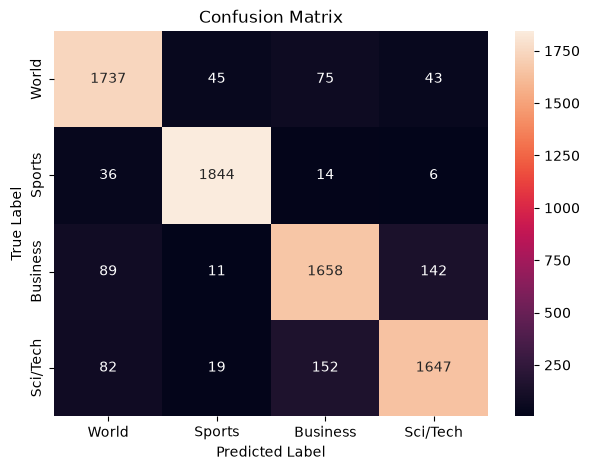

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report 
import seaborn as sns

data_labels = ["World", "Sports", "Business", "Sci/Tech"]
confMatrix = confusion_matrix(np.argmax(y_test, 1), np.argmax(y_pred, 1))

plt.figure(figsize=(7, 5))
sns.heatmap(confMatrix, annot=True, fmt='g', xticklabels=data_labels, yticklabels=data_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

From the confusion matrix we can extract the following information:
* The strongest class performance was observed for the Sports category, were only 3 predictions where mismatched with Sci/Tech class.
* The predictions have an overall accuracy of 90.197% 

In [31]:
truePos = np.trace(confMatrix)
overall_accuracy = truePos / len(y_pred) * 100

truePos = confMatrix[0][0] + confMatrix[1][1] + confMatrix[2][2] + confMatrix[3][3]
print("Correctly predicted: \t", truePos)
print("Number of predictions: \t", len(y_pred))
print("Overall accuracy: \t", overall_accuracy)

Correctly predicted: 	 6886
Number of predictions: 	 7600
Overall accuracy: 	 90.60526315789474


#### Classification Report
Creates a classification report 

In [32]:
# ------ https://hackernoon.com/multiclass-classification-with-keras -------
print(classification_report(
   y_test,
   y_pred_OneHot,
   target_names=["World", "Sports", "Business", "Sci/Tech"]
   ))

              precision    recall  f1-score   support

       World       0.89      0.91      0.90      1900
      Sports       0.96      0.97      0.97      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.90      0.87      0.88      1900

   micro avg       0.91      0.91      0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600
 samples avg       0.91      0.91      0.91      7600



# Evaluation of the Project
## Model Preparation
During the model preparation, the dataset was chosen from Tensorflow libraries, however the data was not part of Keras library. This data was not prepared to be used directly for training a model. Therefore, some data processing was implemented. Initially the data processing was not part of the scope of the project, but I immediately understood the benefit of doing data processing before starting to train the model. 

Data processing helped understand the structure and requirements of the input data of a model. Moreover, it shows how beneficial converting data into tensors of series or tensors of one-hot encoding facilitates the training of a model.

Another crucial step in preparing to train the model was to create functions that could be reused later. This became useful for implementing K-fold validation and for hyperparameter tuning. A vocabulary was needed to convert the data into series. To avoid information leakage when training a K-fold model it was necessary to create the vocabulary for each fold. Therefore the functions were used inside of the for loop. For the model training these functions were useful for parameter tuning because the functions were used inside for loops to try the different parameters. 

One of the most important steps in preparation was to understand what was expected of the model:
* Understanding the data available: two string features of data merged into one and four classes of labels. S
* Finding the problem to solve by the model: one-label multiclass classification.
* Understanding the behavior and applications of different hyperparameters and functions that could be used in a multiclass classification problem.
By understanding these steps in the preparation of the development of the model, the functionality and applications became more clear. 

## Model Functionality
As demonstrated in this project, the model was based on classifying the data of news articles and their titles into one of four categories of news: World, Sports, Business, Sci/Tech. 
Classification is a problem that can be solved by using this multiclass classification model. There are other examples where this model could be beneficial: 
* Classifying doctor notes into types of sickness.
* Separating reviews into different levels
* Classifying books into subjects
* Classifying emails into different categories 
* Predicting animals or plants type based on images or information

The initial baseline for this model was 25% due to the four classes being equally distributed, however this baseline was immediately surpassed with the initial model just above 90%. After tuning the hyperparameters the model was able to improve around 1%, however most of the initial hyperparameters were the optimal. 
Overall, the model has a very high accuracy, however improvements can be done by having a better data preprocessing method by removing some digits and data tokens with higher ranking without meaningful value. 

# Project Improvement
## Limitations
The model achieved approximately 90% test accuracy; however, several limitations remain:

The model uses a simple feed-forward architecture rather than modern transformer-based approaches.
Word order information is largely lost during vectorization.
Hyperparameter tuning was limited by available computational resources.
Results were evaluated on a single dataset and may not generalize to other news domains.

## Future Work
Potential improvements include:

Word embeddings
LSTM networks
GRU networks
Transformer architectures
Pre-trained language models such as BERT
Automated hyperparameter optimization

# Conclusion
In conclusion, this project was based on using a preprocessed dataset that would help in the development of the model. However, a raw dataset was used to better understand the inputs needed for the model. This data set was preprocessed to fit the needs of the deep learning model by using tokenizations, sequencing, vectorization and encoding. 

Once the data was ready, the planning of the model was started by understanding the problem to solve and how the model should be used. Then the data was used to train models that would be compared to choose the optimal option.

The models created were chosen from Simple Hold-out Validation(HOV) and K-fold Validation(KFV) where HOV was the preferred method due to using less resources and having a very similar accuracy score than KFV. The optimal number of epochs was extracted by training a model with 20 epochs where **3 epochs** was the optimal number before the model started to overfit on the validation data.

The next comparison was done by choosing different hyperparameters. The first step was comparing different layers and layer sizes. The best performance was with 3 layers where size 128/64/4 and the input and hidden layer was **Relu** activation function with an output **Softmax**. The loss function remained the same as categorical_crossentropy. And after comparing the optimizer functions the rmsprop was chosen as the best option for the model.

This project was based on understanding how to implement a deep learning model. While I use many combinations of hyperparameters and methods, I still need to learn more about other options available for instance, by applying different learning rates. However, I can now understand the functionality, the parts of a model, the validation and evaluation processes and the tuning of hyperparameters.      


# References

## Works Cited
* “AG News Dataset.” Papers With Code, https://paperswithcode.com/dataset/ag-news. Accessed 22 February 2024.
* “ag_news_subset.” TensorFlow, https://www.tensorflow.org/datasets/catalog/ag_news_subset. Accessed 16 February 2024.
* Brownlee, Jason. “A Gentle Introduction to the Rectified Linear Unit (ReLU) - MachineLearningMastery.com.” Machine Learning Mastery, 20 August 2020, https://machinelearningmastery.com/rectified-linear-activation-function-for-deep-learning-neural-networks/. Accessed 28 February 2024.
* Brownlee, Jason. “How to Choose an Activation Function for Deep Learning - MachineLearningMastery.com.” Machine Learning Mastery, 22 January 2021, https://machinelearningmastery.com/choose-an-activation-function-for-deep-learning/. Accessed 4 March 2024.
* Brownlee, Jason. “How to Choose Loss Functions When Training Deep Learning Neural Networks - MachineLearningMastery.com.” Machine Learning Mastery, 25 August 2020, https://machinelearningmastery.com/how-to-choose-loss-functions-when-training-deep-learning-neural-networks/. Accessed 28 February 2024.
* Brownlee, Jason. “What is a Confusion Matrix in Machine Learning - MachineLearningMastery.com.” Machine Learning Mastery, 15 August 2020, https://machinelearningmastery.com/confusion-matrix-machine-learning/. Accessed 23 February 2024.
* Bushaev, Vitaly. “Adam — latest trends in deep learning optimization. | by Vitaly Bushaev.” Towards Data Science, 22 October 2018, https://towardsdatascience.com/adam-latest-trends-in-deep-learning-optimization-6be9a291375c. Accessed 4 March 2024.
* Chollet, Francois. Deep Learning with Python. First ed., Manning, 2017. https://www.manning.com/, https://www.manning.com/books/deep-learning-with-python. Accessed 14 February 2024.
* Huang, Jason. “RMSProp.” Cornell University Computational Optimization Open Textbook, 21 December 2020, https://optimization.cbe.cornell.edu/index.php?title=RMSProp. Accessed 28 February 2024.
* Jain, Sandeep. “Confusion Matrix in Machine Learning.” GeeksforGeeks, 23 January 2024, https://www.geeksforgeeks.org/confusion-matrix-machine-learning/. Accessed 23 February 2024.
* Jain, Sandeep. “Introduction to Power Analysis in Python.” GeeksforGeeks, 26 March 2021, https://www.geeksforgeeks.org/introduction-to-power-analysis-in-python/. Accessed 27 February 2024.
* Maithani, Mohit. “Complete Guide to Tensorflow Keras Optimizers.” Analytics India Magazine, https://analyticsindiamag.com/guide-to-tensorflow-keras-optimizers/. Accessed 4 March 2024.
* Saeed, Mehreen. “A Gentle Introduction To Sigmoid Function - MachineLearningMastery.com.” Machine Learning Mastery, 18 August 2021, https://machinelearningmastery.com/a-gentle-introduction-to-sigmoid-function/. Accessed 4 March 2024.
* “Softmax: The Activation Function That Drives Neural Networks.” Analytics Vidhya, https://www.analyticsvidhya.com/blog/2021/04/introduction-to-softmax-for-neural-network/. Accessed 4 March 2024.
* T, Kumaran. “Label Encoding vs. One Hot Encoding.” 20 03 2023, https://medium.com/@kumaran.t18/label-encoding-vs-a475f4bdbb60. Accessed 26 February 2024.
* “TensorFlow Datasets: a collection of ready-to-use datasets.” TensorFlow, https://www.tensorflow.org/datasets. Accessed 16 February 2024.
* Washington.edu. “Chapter 6 Logistic Regression 6.1 MSE / Convexity.” Washington, https://courses.cs.washington.edu/courses/cse416/22su/lectures/6/lecture_6.pdf. Accessed 4 March 2024.
